In [1]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import normalized_mutual_info_score as nmi
from scipy.spatial.distance import cdist, pdist, squareform


import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
import patchworklib as pw

import sys

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.plotting import plot_embedding
from scLEMBAS import preprocess



[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

<Figure size 100x100 with 0 Axes>

In [2]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

Load files:

In [21]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'interim', 'Kang_tf_activity.h5ad'))
tf_adata.obs.rename(columns = {'leiden': 'gene_clusters'}, inplace = True)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [24]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Filter for TFs retained ni the signaling network:

In [25]:
tf_labels = tf_adata.var.index.unique().tolist()
og_n = len(tf_labels)

included_nodes = sorted(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
tf_labels = [tf for tf in tf_labels if tf in included_nodes]
print('{} of {} TFs are present in the signaling network'.format(len(tf_labels), og_n))
tf_adata = tf_adata[:,tf_labels]


240 of 423 TFs are present in the signaling network


Embed while maximizing NMI between clusters and cell type + stim annotation: 

In [12]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs.drop(columns = ['TF_clusters'], inplace = True)

In [15]:
tf_adata.obs['condition'] = tf_adata.obs.stim.astype(str) + '^' + tf_adata.obs.seurat_annotations.astype(str)
preprocess.embed_tf_activity(tf_adata = tf_adata, scanpy_pca = False, 
                             n_components = 50, 
                             cluster_col_name = 'TF_clusters',
                            resolution = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0], 
                            nmi_label = 'condition')
tf_adata.obs.drop(columns = ['condition'], inplace = True)

Iterate through leiden resolutions


100%|█████████████████████████████████████████████| 6/6 [00:11<00:00,  1.83s/it]


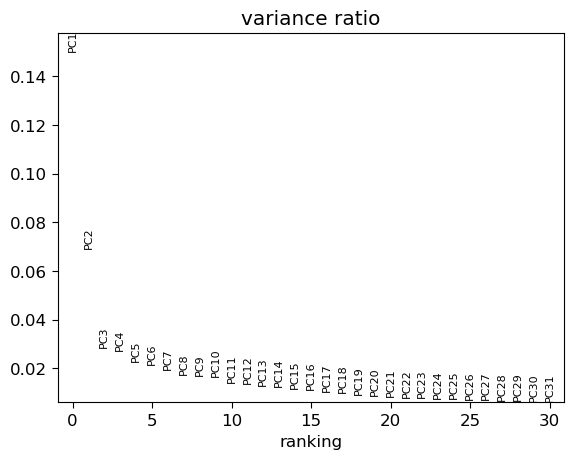

The elbow was automatically identified at PC 5


In [16]:
sc.pl.pca_variance_ratio(tf_adata)
print('The elbow was automatically identified at PC {}'.format(tf_adata.uns['pca']['pca_rank']))

Visualize:

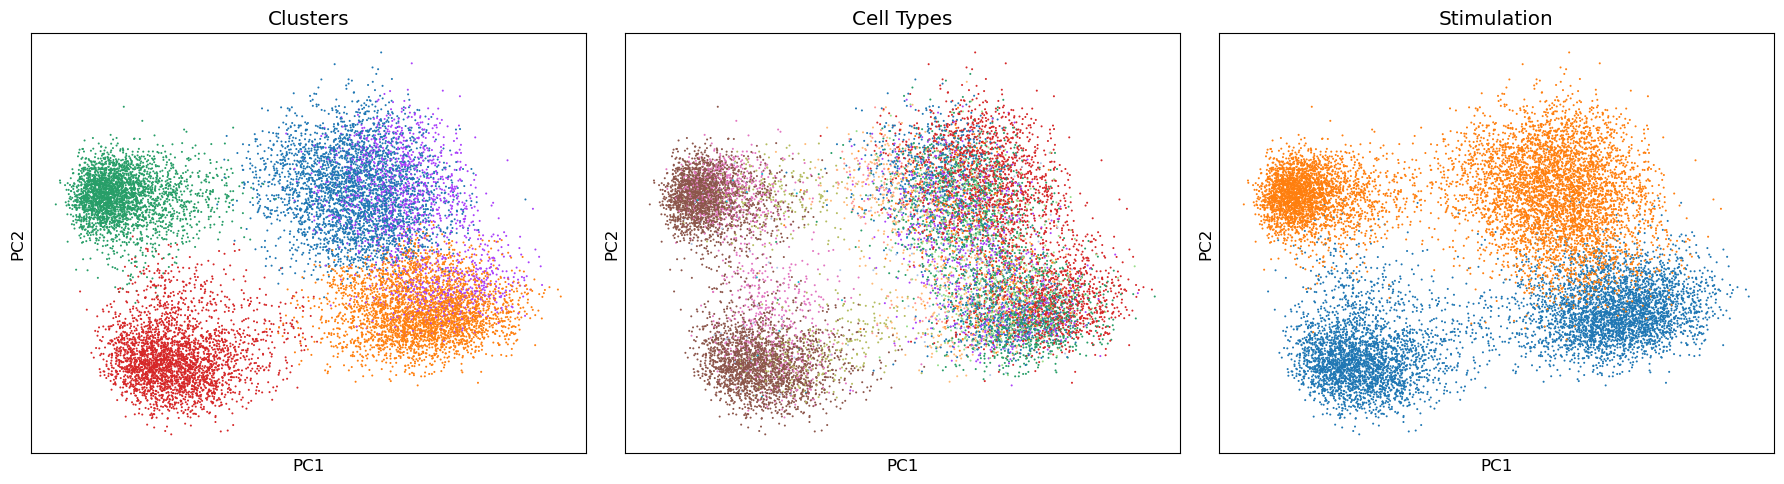

In [18]:
fig, ax = plt.subplots(ncols = 3, figsize = (18, 5))

sc.pl.pca(tf_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.pca(tf_adata, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.pca(tf_adata, color='stim', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_tf_adata.obs.TF_clusters, tf_tf_adata.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

TF activity is separating well in PC space, so this is good

In [19]:
cat_cov = ['gene_clusters', 'TF_clusters', 'seurat_annotations', 'stim']
NMI_df = pd.DataFrame(columns = ['NMI'], 
                      index = ['^'.join(comb) for comb in itertools.combinations(cat_cov, 2)])
for comb in NMI_df.index:
    NMI_df.loc[comb, 'NMI'] = nmi(tf_adata.obs[comb.split('^')[0]], tf_adata.obs[comb.split('^')[1]])
    
NMI_df

,NMI
gene_clusters^TF_clusters,0.448698
gene_clusters^seurat_annotations,0.450357
gene_clusters^stim,0.284544
TF_clusters^seurat_annotations,0.376993
TF_clusters^stim,0.421422
seurat_annotations^stim,0.003175


In fact, the clustering which is based on PC separation shows better agreement with the stimulation condition than the gene activity

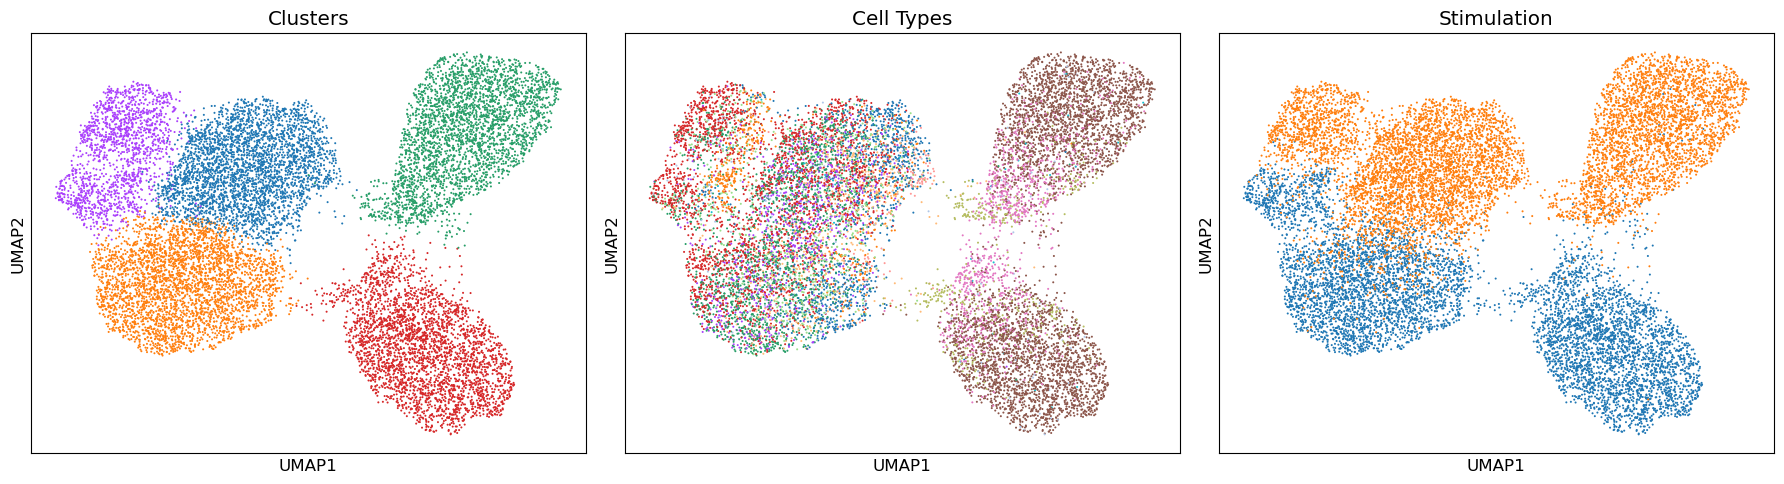

In [20]:
fig, ax = plt.subplots(ncols = 3, figsize = (18, 5))

sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.umap(tf_adata, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.umap(tf_adata, color='stim', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_tf_adata.obs.TF_clusters, tf_tf_adata.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

In [21]:
io.write_tfad(tf_adata, os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))